# Minimizing Churn Rate Through Analysis of Financial Habits
## Industry-Grade ML Pipeline — Applied AI & ML Course

**This notebook demonstrates a production-style ML workflow used in top MNCs:**
- Advanced Feature Engineering
- Sklearn Preprocessor Pipelines
- StratifiedShuffleSplit for robust train/test splitting
- Training Multiple Models in a Loop
- Cross-Validation for reliable evaluation
- Optuna for Hyperparameter Optimization
- Custom Evaluation Function (AUC + Decile Lift)

---
## Step 1: Import Libraries

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings, os
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# ── Sklearn: Splitting ────────────────────────────────────────────────────────
from sklearn.model_selection import (
    StratifiedShuffleSplit,   # Industry-standard stratified split
    cross_val_score,
    StratifiedKFold
)

# ── Sklearn: Preprocessing ────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder

# ── Sklearn: Models ───────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── Sklearn: Metrics ──────────────────────────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Optuna: Hyperparameter Optimization ───────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Suppress verbose logs

# ── Output directory for plots ────────────────────────────────────────────────
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

pd.set_option('display.max_columns', None)
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Step 2: Load & Initial Inspection

In [5]:
# Load data
df_raw = pd.read_csv(r'C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\ML_Project\churn_data\churn_data.csv')
print(f"Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Shape: (27000, 31)


,user,churn,age,housing,credit_score,deposits,withdrawal,purchases_partners,purchases,cc_taken,cc_recommended,cc_disliked,cc_liked,cc_application_begin,app_downloaded,web_user,app_web_user,ios_user,android_user,registered_phones,payment_type,waiting_4_loan,cancelled_loan,received_loan,rejected_loan,zodiac_sign,left_for_two_month_plus,left_for_one_month,rewards_earned,reward_rate,is_referred
0,55409,0,37.0,na,NaN,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,Bi-Weekly,0,0,0,0,Leo,1,0,NaN,0.00,0
1,23547,0,28.0,R,486.0,0,0,1,0,0,96,0,0,5,1,1,1,1,0,0,Weekly,0,0,0,0,Leo,0,0,44.0,1.47,1
2,58313,0,35.0,R,561.0,47,2,86,47,0,285,0,0,9,1,0,0,0,1,2,Semi-Monthly,0,0,0,0,Capricorn,1,0,65.0,2.17,0
3,8095,0,26.0,R,567.0,26,3,38,25,0,74,0,0,26,1,0,0,0,1,0,Bi-Weekly,0,0,0,0,Capricorn,0,0,33.0,1.10,1
4,61353,1,27.0,na,NaN,0,0,2,0,0,0,0,0,0,1,1,1,0,1,0,Bi-Weekly,0,0,0,0,Aries,1,0,1.0,0.03,0


In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 27000 entries, 0 to 26999
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user                     27000 non-null  int64  
 1   churn                    27000 non-null  int64  
 2   age                      26996 non-null  float64
 3   housing                  27000 non-null  str    
 4   credit_score             18969 non-null  float64
 5   deposits                 27000 non-null  int64  
 6   withdrawal               27000 non-null  int64  
 7   purchases_partners       27000 non-null  int64  
 8   purchases                27000 non-null  int64  
 9   cc_taken                 27000 non-null  int64  
 10  cc_recommended           27000 non-null  int64  
 11  cc_disliked              27000 non-null  int64  
 12  cc_liked                 27000 non-null  int64  
 13  cc_application_begin     27000 non-null  int64  
 14  app_downloaded           27000 no

In [7]:
# Target column distribution
print("Target Distribution:")
print(df_raw['churn'].value_counts())
print(f"\nChurn Rate: {df_raw['churn'].mean():.2%}")

Target Distribution:
churn
0    15826
1    11174
Name: count, dtype: int64

Churn Rate: 41.39%


---
## Step 3: Data Cleaning

> **Industry Note:** In real projects, `'na'` strings must be converted to `NaN` before any processing. Failing to do this leads to **silent bugs** in imputation and encoding.

In [8]:
df_raw.isna().any()

user                       False
churn                      False
age                         True
housing                    False
credit_score                True
deposits                   False
withdrawal                 False
purchases_partners         False
purchases                  False
cc_taken                   False
cc_recommended             False
cc_disliked                False
cc_liked                   False
cc_application_begin       False
app_downloaded             False
web_user                   False
app_web_user               False
ios_user                   False
android_user               False
registered_phones          False
payment_type               False
waiting_4_loan             False
cancelled_loan             False
received_loan              False
rejected_loan              False
zodiac_sign                False
left_for_two_month_plus    False
left_for_one_month         False
rewards_earned              True
reward_rate                False
is_referre

In [9]:
df_raw.isna().sum()

user                          0
churn                         0
age                           4
housing                       0
credit_score               8031
deposits                      0
withdrawal                    0
purchases_partners            0
purchases                     0
cc_taken                      0
cc_recommended                0
cc_disliked                   0
cc_liked                      0
cc_application_begin          0
app_downloaded                0
web_user                      0
app_web_user                  0
ios_user                      0
android_user                  0
registered_phones             0
payment_type                  0
waiting_4_loan                0
cancelled_loan                0
received_loan                 0
rejected_loan                 0
zodiac_sign                   0
left_for_two_month_plus       0
left_for_one_month            0
rewards_earned             3227
reward_rate                   0
is_referred                   0
dtype: i

In [10]:
# Replace string 'na' with actual NaN
df = df_raw.replace('na', np.nan).copy()

# Drop identifier column — not a predictive feature
df.drop(columns=['user'], inplace=True)

# Rename target column to standard convention used in evaluate_model()
df.rename(columns={'churn': 'TARGET'}, inplace=True)

# Check missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
housing,13860,51.333333
credit_score,8031,29.744444
payment_type,3899,14.440741
rewards_earned,3227,11.951852
zodiac_sign,2159,7.996296
age,4,0.014815


---
## Step 4: Exploratory Data Analysis (EDA)

In [11]:
# Identify numeric and categorical columns (excluding target)
CAT_COLS = ['housing', 'payment_type', 'zodiac_sign']
NUM_COLS = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'TARGET']

print(f"Numeric columns  : {len(NUM_COLS)}")
print(f"Categorical cols : {len(CAT_COLS)}")
print(f"Target           : TARGET")

Numeric columns  : 26
Categorical cols : 3
Target           : TARGET


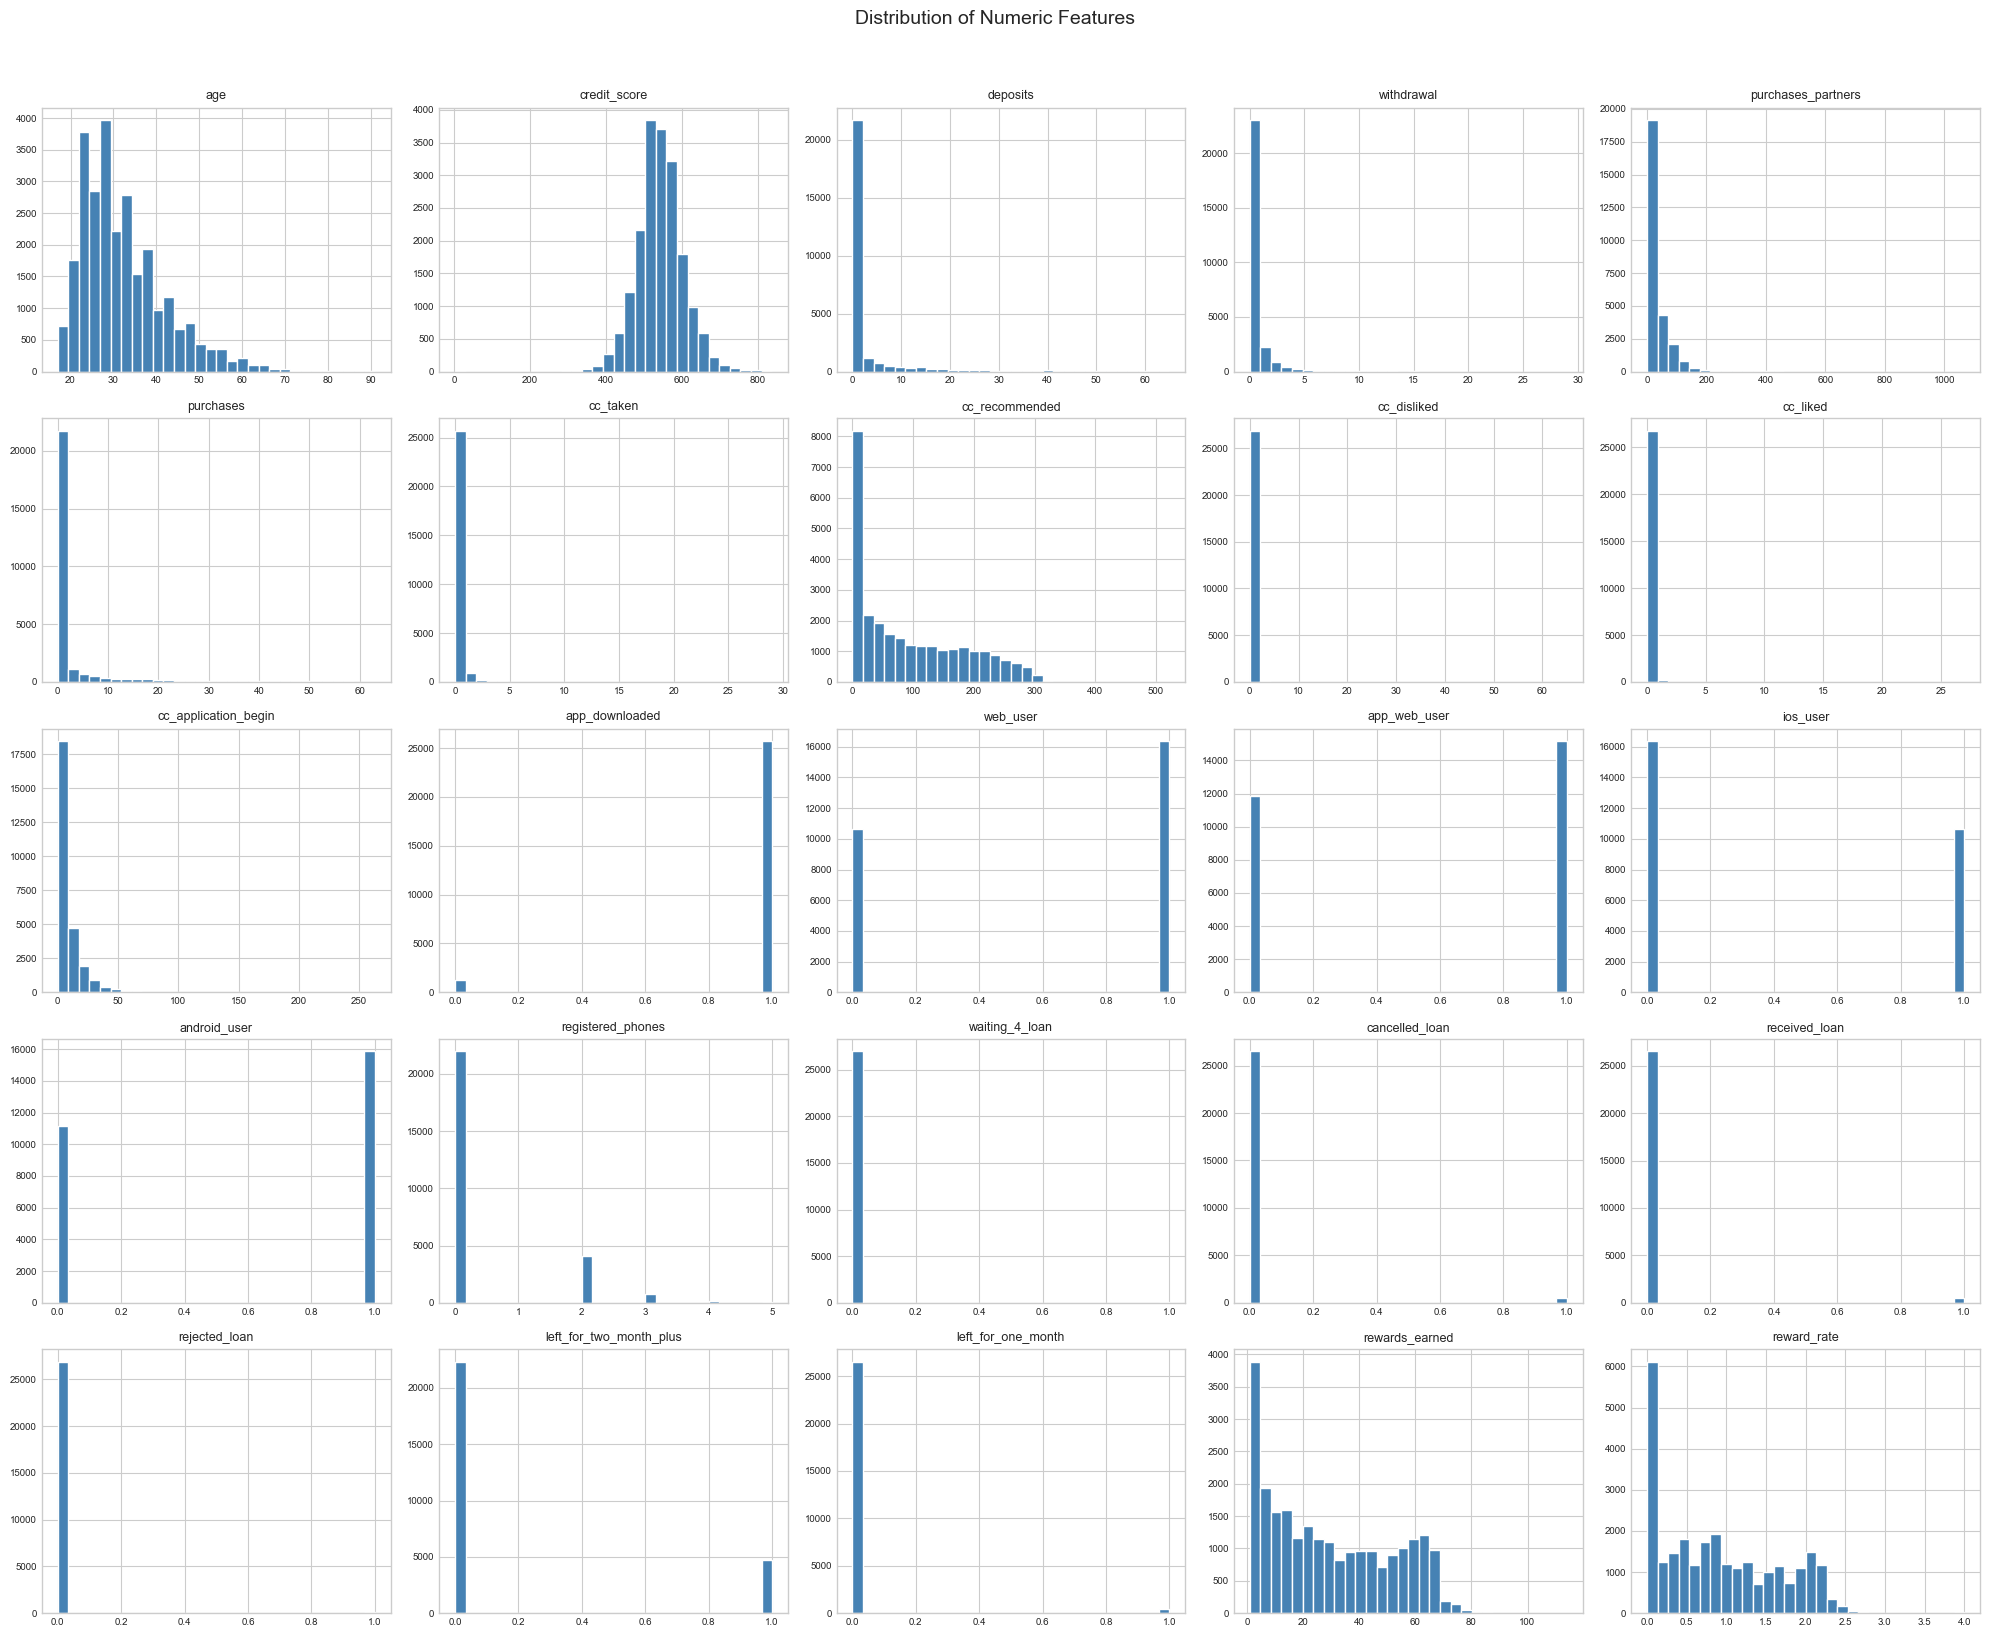

In [12]:
# Distribution plots for numeric features
fig, axes = plt.subplots(5, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS[:25]):
    df[col].hist(ax=axes[i], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle("Distribution of Numeric Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/numeric_distributions.png", bbox_inches='tight', dpi=100)
plt.show()

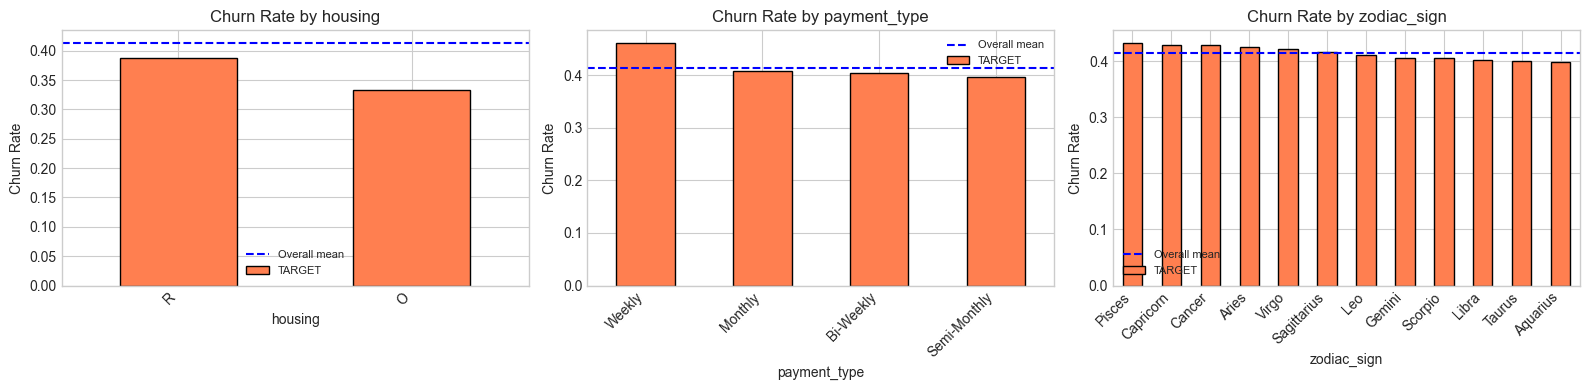

In [13]:
# Churn rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, CAT_COLS):
    churn_rate = df.groupby(col)['TARGET'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.axhline(df['TARGET'].mean(), color='blue', linestyle='--', label='Overall mean')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/churn_by_categorical.png", bbox_inches='tight', dpi=100)
plt.show()

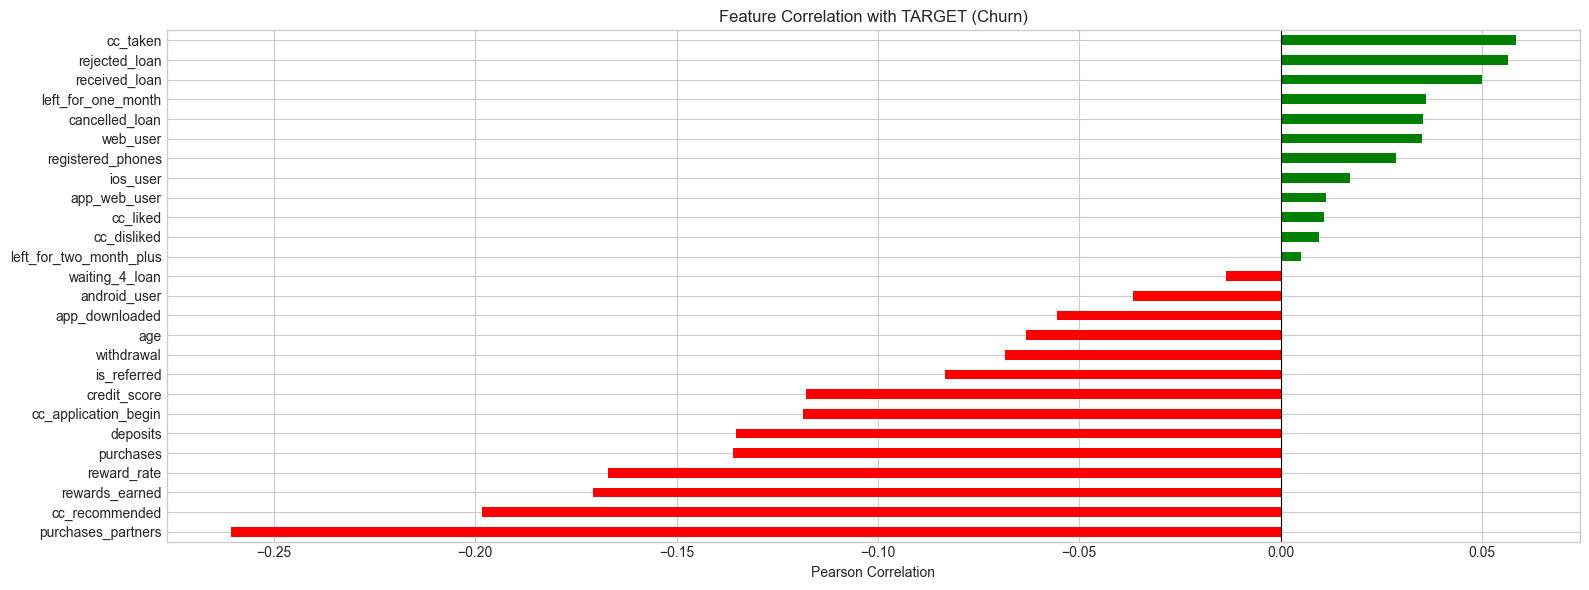

In [14]:
# Correlation heatmap of numeric features vs target
plt.figure(figsize=(16, 6))
corr_with_target = df[NUM_COLS + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()
corr_with_target.plot(kind='barh', color=['green' if v > 0 else 'red' for v in corr_with_target])
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with TARGET (Churn)")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/correlation_with_target.png", bbox_inches='tight', dpi=100)
plt.show()

---
## Step 5: Advanced Feature Engineering

> **Industry Insight:** Raw features rarely tell the full story. Feature Engineering creates *new signals* that expose hidden patterns in the data. This step often gives **the biggest boost** to model performance — more than hyperparameter tuning.

In [15]:
def create_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Industry-grade feature engineering function.
    All new features are derived from domain knowledge of fintech churn.
    
    IMPORTANT: This function is applied BEFORE the train/test split
    because we are only creating ratio/interaction features — no
    aggregations that could cause data leakage.
    """
    df = data.copy()
    
    # ── 1. Engagement Features ─────────────────────────────────────────────
    # Ratio: partner purchases vs total purchases → indicates engagement type
    df['purchases_partner_ratio'] = np.where(
        df['purchases'] > 0,
        df['purchases_partners'] / (df['purchases'] + 1),
        0
    )

    # Total transaction volume
    df['total_transactions'] = df['deposits'] + df['withdrawal'] + df['purchases']

    # Net cash flow: deposits minus withdrawals
    df['net_cashflow'] = df['deposits'] - df['withdrawal']

    # App engagement score (multi-platform = more engaged)
    df['platform_usage_score'] = (
        df['app_downloaded'] + df['web_user'] +
        df['app_web_user'] + df['ios_user'] + df['android_user']
    )

    # ── 2. Credit Card Behaviour Features ─────────────────────────────────
    # CC engagement: recommended vs liked → shows interest alignment
    df['cc_engagement_ratio'] = np.where(
        df['cc_recommended'] > 0,
        df['cc_liked'] / (df['cc_recommended'] + 1),
        0
    )

    # CC dislike ratio: disliked / recommended → dissatisfaction signal
    df['cc_dissatisfaction_ratio'] = np.where(
        df['cc_recommended'] > 0,
        df['cc_disliked'] / (df['cc_recommended'] + 1),
        0
    )

    # ── 3. Loan Behaviour Features ─────────────────────────────────────────
    # Total loan interactions
    df['loan_interactions'] = (
        df['waiting_4_loan'] + df['cancelled_loan'] +
        df['received_loan'] + df['rejected_loan']
    )

    # Loan rejection rate (high rejection = frustration = churn signal)
    df['loan_rejection_rate'] = np.where(
        df['loan_interactions'] > 0,
        df['rejected_loan'] / (df['loan_interactions'] + 1),
        0
    )

    # ── 4. Reward & Loyalty Features ──────────────────────────────────────
    # High reward rate users are likely more loyal
    df['high_reward_user'] = (df['reward_rate'] > df['reward_rate'].median()).astype(int)

    # ── 5. Absence / Inactivity Features ──────────────────────────────────
    # Combined absence flag: left for extended period → strong churn predictor
    df['prolonged_absence'] = np.where(
        (df['left_for_two_month_plus'] == 1) | (df['left_for_one_month'] == 1),
        1, 0
    )

    # ── 6. Age Buckets (Ordinal Feature) ──────────────────────────────────
    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 25, 35, 45, 100],
        labels=['18-25', '26-35', '36-45', '45+']
    ).astype(str)  # Convert to string for OHE

    return df


df_fe = create_features(df)

# Show new features
new_features = [
    'purchases_partner_ratio', 'total_transactions', 'net_cashflow',
    'platform_usage_score', 'cc_engagement_ratio', 'cc_dissatisfaction_ratio',
    'loan_interactions', 'loan_rejection_rate', 'high_reward_user',
    'prolonged_absence', 'age_group'
]
print(f"✅ Feature Engineering complete. New features created: {len(new_features)}")
df_fe[new_features].head()

✅ Feature Engineering complete. New features created: 11


,purchases_partner_ratio,total_transactions,net_cashflow,platform_usage_score,cc_engagement_ratio,cc_dissatisfaction_ratio,loan_interactions,loan_rejection_rate,high_reward_user,prolonged_absence,age_group
0,0.000000,0,0,4,0.0,0.0,0,0.0,0,1,36-45
1,0.000000,0,0,4,0.0,0.0,0,0.0,1,0,26-35
2,1.791667,96,45,2,0.0,0.0,0,0.0,1,1,26-35
3,1.461538,54,23,2,0.0,0.0,0,0.0,1,0,26-35
4,0.000000,0,0,4,0.0,0.0,0,0.0,0,1,26-35


---
## Step 6: Train/Test Split using StratifiedShuffleSplit

> **Why StratifiedShuffleSplit?**  
> In imbalanced datasets (like churn), a simple `train_test_split` might accidentally give you different churn rates in train vs test.  
> `StratifiedShuffleSplit` **guarantees** the same churn proportion in both splits — this is the industry standard.

In [16]:
# ── Define final feature columns ──────────────────────────────────────────────
CAT_COLS_FE = ['housing', 'payment_type', 'zodiac_sign', 'age_group']
NUM_COLS_FE  = [
    c for c in df_fe.columns
    if c not in CAT_COLS_FE + ['TARGET']
    and df_fe[c].dtype in ['float64', 'int64']
]

ALL_FEATURES = NUM_COLS_FE + CAT_COLS_FE
TARGET_COL   = 'TARGET'

X = df_fe[ALL_FEATURES]
y = df_fe[TARGET_COL]

print(f"Features: {len(ALL_FEATURES)}  (Numeric: {len(NUM_COLS_FE)}, Categorical: {len(CAT_COLS_FE)})")
print(f"Total samples: {len(X)}")

# ── StratifiedShuffleSplit ────────────────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"Train churn rate : {y_train.mean():.4f}")
print(f"Test churn rate  : {y_test.mean():.4f}")
print("✅ Churn rate is consistent in both splits — StratifiedShuffleSplit worked!")

Features: 40  (Numeric: 36, Categorical: 4)
Total samples: 27000

Train: (21600, 40) | Test: (5400, 40)
Train churn rate : 0.4138
Test churn rate  : 0.4139
✅ Churn rate is consistent in both splits — StratifiedShuffleSplit worked!


---
## Step 7: Preprocessing Pipeline

> **Industry Best Practice:**  
> Always use a **`Pipeline`** + **`ColumnTransformer`** instead of manually transforming columns.  
> This ensures:  
> - Imputation statistics are learned on **train only** (no data leakage)  
> - The same transformations apply consistently at inference  
> - One clean, reproducible object that can be saved and reloaded

In [17]:
# ── Numeric pipeline: Impute → Normalize ──────────────────────────────────────
# StandardScaler: zero mean, unit variance (best for logistic regression)
# MinMaxScaler: scale to [0,1] (good for tree-based models too, but mainly for LR)
# We use StandardScaler here as it's the most common industry choice

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # Median is robust to outliers
    ('scaler',  StandardScaler())                     # Normalize: z = (x - mean) / std
])

# ── Categorical pipeline: Impute → One-Hot Encode ─────────────────────────────
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── Combine into ColumnTransformer ────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,     NUM_COLS_FE),
    ('cat', categorical_pipeline, CAT_COLS_FE)
])

# ── Fit on train, transform both train and test ────────────────────────────────
# CRITICAL: .fit_transform on train only, .transform on test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Processed Train shape : {X_train_proc.shape}")
print(f"Processed Test shape  : {X_test_proc.shape}")
print("✅ Preprocessor fitted on train data only — no data leakage!")

Processed Train shape : (21600, 58)
Processed Test shape  : (5400, 58)
✅ Preprocessor fitted on train data only — no data leakage!


---
## Step 8: Define Evaluation Function

In [18]:
def evaluate_model(eval_df, plot_output_location):
    """
    :param eval_df: A DataFrame containing evaluation data (TARGET, probs)
    :param plot_output_location: Path where plots should be saved.
    :returns:
        - auc: AUC metric for the ROC curve
        - lift_tenth_decile: Lift value for the 10th decile
    """
    eval_df = eval_df.copy()
    eval_df["decile"] = pd.qcut(eval_df["probs"], 10, labels=False) + 1

    # ROC curve and AUC
    auc = roc_auc_score(eval_df["TARGET"], eval_df["probs"])
    fpr, tpr, thresholds = roc_curve(eval_df["TARGET"], eval_df["probs"])
    gmeans = np.sqrt(tpr * (1 - fpr))
    index = np.argmax(gmeans)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC curve (area = {auc:.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.plot(fpr[index], tpr[index], "ro")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.savefig(f"{plot_output_location}/roc_curve.png")
    plt.close()

    # Decile lift chart
    lift_df = (
        eval_df.groupby("decile")
        .agg(total_count=("TARGET", "count"), attriters=("TARGET", "sum"))
        .reset_index()
    )
    lift_df["attrition_rate"] = lift_df["attriters"] / lift_df["total_count"]
    lift_df["cumulative_attrition_rate"] = (
        lift_df["attriters"].cumsum() / lift_df["total_count"].cumsum()
    )
    lift_df["lift"] = lift_df["attrition_rate"] / eval_df["TARGET"].mean()
    lift_df = lift_df.sort_values("decile", ascending=False)
    lift_tenth_decile = lift_df.loc[lift_df["decile"] == 10, "lift"].iloc[0]

    # Plot lift
    plt.figure()
    plt.axhline(y=1.0, color="r", linestyle="--")
    plt.plot(lift_df["decile"], lift_df["lift"], marker="o")
    plt.xlabel("Decile")
    plt.ylabel("Lift")
    plt.title("Decile Lift Chart")
    plt.gca().invert_xaxis()
    plt.savefig(f"{plot_output_location}/lift_curve.png")
    plt.close()

    return auc, lift_tenth_decile

print("✅ evaluate_model() function defined.")

✅ evaluate_model() function defined.


---
## Step 9: Train Multiple Models in a Loop

> **Industry Pattern:**  
> In real projects, we never train just one model. We define a **model dictionary** and loop through all of them. This allows us to compare fairly and pick the best one before investing time in hyperparameter tuning.

In [19]:
# ── Model Dictionary ─────────────────────────────────────────────────────────
# Each key = model name, each value = untrained model instance

MODEL_DICT = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":        DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost":              XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='auc', verbosity=0),
    "LightGBM":             LGBMClassifier(n_estimators=100, random_state=42,
                                           verbose=-1)
}

print(f"Models to train: {list(MODEL_DICT.keys())}")

Models to train: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']


In [20]:
# ── Train all models in a loop + collect metrics ──────────────────────────────

results_list = []  # Will be converted to DataFrame for comparison
trained_models = {}  # Store trained models for later use

# Cross-validation strategy: 5-fold stratified
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training models...\n")

for model_name, model in MODEL_DICT.items():
    print(f"  ▶ {model_name}")

    # ── Train on full training data ──────────────────────────────────────────
    model.fit(X_train_proc, y_train)
    trained_models[model_name] = model

    # ── Predict probabilities on test set ───────────────────────────────────
    y_prob = model.predict_proba(X_test_proc)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # ── Cross-validation AUC (on train) ─────────────────────────────────────
    cv_scores = cross_val_score(
        model, X_train_proc, y_train,
        cv=cv_strategy, scoring='roc_auc', n_jobs=-1
    )

    # ── AUC + Decile Lift via evaluate_model() ───────────────────────────────
    eval_df_temp = pd.DataFrame({'TARGET': y_test.values, 'probs': y_prob})
    model_plot_dir = f"{PLOT_DIR}/{model_name.replace(' ', '_')}"
    os.makedirs(model_plot_dir, exist_ok=True)
    auc, lift_10th = evaluate_model(eval_df_temp, model_plot_dir)

    # ── Collect all metrics ──────────────────────────────────────────────────
    results_list.append({
        'Model':               model_name,
        'Test AUC':            round(auc, 4),
        'CV AUC Mean':         round(cv_scores.mean(), 4),
        'CV AUC Std':          round(cv_scores.std(), 4),
        'Accuracy':            round(accuracy_score(y_test, y_pred), 4),
        'Precision':           round(precision_score(y_test, y_pred), 4),
        'Recall':              round(recall_score(y_test, y_pred), 4),
        'F1 Score':            round(f1_score(y_test, y_pred), 4),
        'Lift (10th Decile)':  round(lift_10th, 4)
    })

print("\n✅ All models trained and evaluated!")

Training models...

  ▶ Logistic Regression
  ▶ Decision Tree
  ▶ Random Forest
  ▶ Gradient Boosting
  ▶ XGBoost
  ▶ LightGBM

✅ All models trained and evaluated!


In [21]:
# ── Model Comparison DataFrame ────────────────────────────────────────────────
results_df = pd.DataFrame(results_list).sort_values('Test AUC', ascending=False)
results_df.set_index('Model', inplace=True)

# Highlight best values
results_df.style.highlight_max(
    subset=['Test AUC', 'CV AUC Mean', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Lift (10th Decile)'],
    color='lightgreen'
).highlight_min(
    subset=['CV AUC Std'],
    color='lightblue'
)

,Test AUC,CV AUC Mean,CV AUC Std,Accuracy,Precision,Recall,F1 Score,Lift (10th Decile)
Model,,,,,,,,
Random Forest,0.808500,0.789300,0.005100,0.738900,0.713200,0.617400,0.661900,1.983800
LightGBM,0.798700,0.787500,0.008400,0.725200,0.695300,0.598200,0.643100,2.058200
XGBoost,0.797600,0.783200,0.006800,0.729300,0.694500,0.617400,0.653700,2.067100
Gradient Boosting,0.771800,0.764500,0.008600,0.709800,0.683500,0.556600,0.613600,1.968700
Decision Tree,0.761300,0.742200,0.008400,0.703100,0.668600,0.560600,0.609900,1.958400
Logistic Regression,0.707400,0.699800,0.004000,0.652800,0.598700,0.488600,0.538100,1.655500


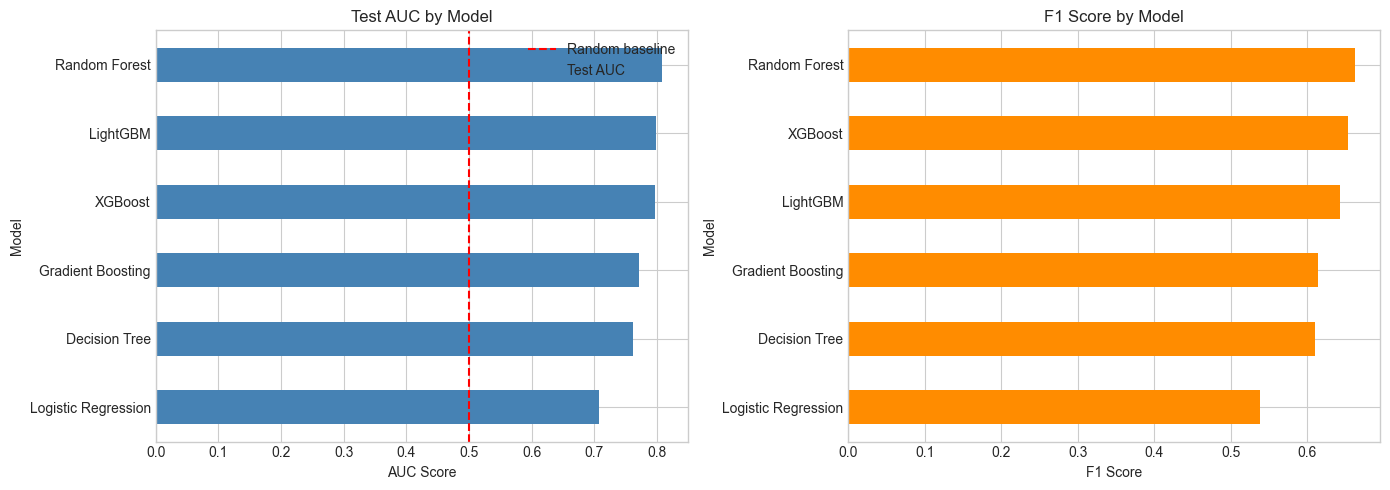


🏆 Best model: Random Forest (AUC = 0.8085)


In [22]:
# ── Visual comparison ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['Test AUC'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Test AUC by Model")
axes[0].set_xlabel("AUC Score")
axes[0].axvline(0.5, color='red', linestyle='--', label='Random baseline')
axes[0].legend()

results_df['F1 Score'].sort_values().plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title("F1 Score by Model")
axes[1].set_xlabel("F1 Score")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/model_comparison.png", bbox_inches='tight', dpi=100)
plt.show()

# Select best model
BEST_MODEL_NAME = results_df['Test AUC'].idxmax()
print(f"\n🏆 Best model: {BEST_MODEL_NAME} (AUC = {results_df.loc[BEST_MODEL_NAME, 'Test AUC']})")

---
## Step 10: Cross-Validation Deep Dive

> **Why Cross-Validation?**  
> A single train/test split can be *lucky or unlucky*. Cross-validation runs the evaluation **5 times on different splits** and gives you a reliable estimate of model performance with confidence intervals.  
> If CV AUC ≈ Test AUC → model is robust. If they differ a lot → overfitting.

In [23]:
# ── Detailed CV analysis for top 3 models ────────────────────────────────────
top_3_models = results_df['Test AUC'].nlargest(3).index.tolist()

print("Cross-Validation Analysis (5-Fold Stratified)\n")
print(f"{'Model':<25} {'Fold 1':>8} {'Fold 2':>8} {'Fold 3':>8} {'Fold 4':>8} {'Fold 5':>8} {'Mean':>8} {'Std':>8}")
print("-" * 80)

for model_name in top_3_models:
    model = trained_models[model_name]
    cv_scores = cross_val_score(
        model, X_train_proc, y_train,
        cv=cv_strategy, scoring='roc_auc', n_jobs=-1
    )
    fold_strs = '  '.join([f"{s:.4f}" for s in cv_scores])
    print(f"{model_name:<25} {fold_strs}   {cv_scores.mean():.4f}   ±{cv_scores.std():.4f}")

Cross-Validation Analysis (5-Fold Stratified)

Model                       Fold 1   Fold 2   Fold 3   Fold 4   Fold 5     Mean      Std
--------------------------------------------------------------------------------
Random Forest             0.7859  0.7895  0.7917  0.7822  0.7973   0.7893   ±0.0051
LightGBM                  0.7814  0.7956  0.7858  0.7764  0.7984   0.7875   ±0.0084
XGBoost                   0.7780  0.7886  0.7781  0.7774  0.7940   0.7832   ±0.0068


---
## Step 11: Hyperparameter Tuning with Optuna

> **What is Optuna?**  
> Optuna is a state-of-the-art **automatic hyperparameter optimization** framework used at companies like Preferred Networks, Mercari, and many top ML teams.  
> It uses **Bayesian Optimization** (Tree-structured Parzen Estimator) — far smarter than Grid Search or Random Search.  
> It learns from past trials to suggest better hyperparameters each time.

In [24]:
# ── Optuna: Optimize the best model ──────────────────────────────────────────
print(f"⚙️  Tuning: {BEST_MODEL_NAME} with Optuna\n")

def get_optuna_objective(model_name: str):
    """
    Returns an Optuna objective function for the given model.
    Each trial suggests a different set of hyperparameters.
    We use 3-fold CV to evaluate — faster but still reliable.
    """
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    if model_name == "XGBoost" or model_name == "Gradient Boosting" or model_name == "LightGBM":

        def objective(trial):
            if model_name == "XGBoost":
                params = {
                    'n_estimators':      trial.suggest_int('n_estimators', 50, 400),
                    'max_depth':         trial.suggest_int('max_depth', 3, 10),
                    'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                    'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
                    'gamma':             trial.suggest_float('gamma', 0, 1),
                    'random_state': 42, 'eval_metric': 'auc', 'verbosity': 0
                }
                model = XGBClassifier(**params)

            elif model_name == "LightGBM":
                params = {
                    'n_estimators':    trial.suggest_int('n_estimators', 50, 400),
                    'max_depth':       trial.suggest_int('max_depth', 3, 12),
                    'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                    'num_leaves':      trial.suggest_int('num_leaves', 20, 200),
                    'subsample':       trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree':trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'random_state': 42, 'verbose': -1
                }
                model = LGBMClassifier(**params)

            else:  # Gradient Boosting
                params = {
                    'n_estimators':  trial.suggest_int('n_estimators', 50, 300),
                    'max_depth':     trial.suggest_int('max_depth', 2, 8),
                    'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                    'subsample':     trial.suggest_float('subsample', 0.5, 1.0),
                    'random_state':  42
                }
                model = GradientBoostingClassifier(**params)

            scores = cross_val_score(
                model, X_train_proc, y_train,
                cv=cv, scoring='roc_auc', n_jobs=-1
            )
            return scores.mean()

    elif model_name == "Random Forest":
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 400),
                'max_depth':    trial.suggest_int('max_depth', 3, 20),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                'random_state': 42, 'n_jobs': -1
            }
            model = RandomForestClassifier(**params)
            scores = cross_val_score(
                model, X_train_proc, y_train,
                cv=cv, scoring='roc_auc', n_jobs=-1
            )
            return scores.mean()

    else:
        def objective(trial):
            params = {
                'C':      trial.suggest_float('C', 0.001, 100, log=True),
                'solver': trial.suggest_categorical('solver', ['lbfgs', 'saga']),
                'max_iter': 1000, 'random_state': 42
            }
            model = LogisticRegression(**params)
            scores = cross_val_score(
                model, X_train_proc, y_train,
                cv=cv, scoring='roc_auc', n_jobs=-1
            )
            return scores.mean()

    return objective


# ── Run Optuna study ──────────────────────────────────────────────────────────
study = optuna.create_study(direction='maximize')  # maximize AUC
study.optimize(
    get_optuna_objective(BEST_MODEL_NAME),
    n_trials=30,           # Try 30 different hyperparameter combinations
    show_progress_bar=True
)

print(f"\n✅ Optuna finished!")
print(f"Best CV AUC  : {study.best_value:.4f}")
print(f"Best Params  : {study.best_params}")

⚙️  Tuning: Random Forest with Optuna



Best trial: 20. Best value: 0.785518: 100%|██████████| 30/30 [00:42<00:00,  1.42s/it]


✅ Optuna finished!
Best CV AUC  : 0.7855
Best Params  : {'n_estimators': 274, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


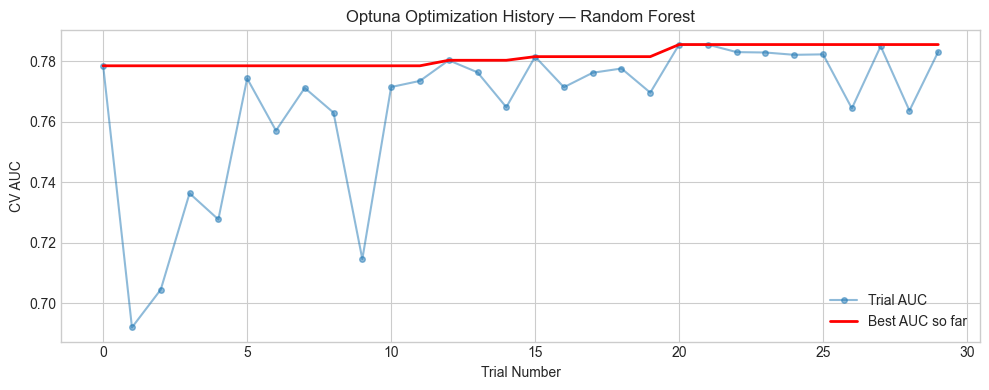

In [25]:
# ── Optuna Visualization: Optimization History ────────────────────────────────
trial_values = [t.value for t in study.trials]
best_so_far = [max(trial_values[:i+1]) for i in range(len(trial_values))]

plt.figure(figsize=(10, 4))
plt.plot(trial_values, alpha=0.5, label='Trial AUC', marker='o', markersize=4)
plt.plot(best_so_far, color='red', linewidth=2, label='Best AUC so far')
plt.xlabel("Trial Number")
plt.ylabel("CV AUC")
plt.title(f"Optuna Optimization History — {BEST_MODEL_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/optuna_history.png", bbox_inches='tight', dpi=100)
plt.show()

---
## Step 12: Final Model — Train with Best Hyperparameters

In [26]:
# ── Build final model using Optuna's best params ──────────────────────────────
best_params = study.best_params

if BEST_MODEL_NAME == "XGBoost":
    final_model = XGBClassifier(**best_params, eval_metric='auc', verbosity=0)
elif BEST_MODEL_NAME == "LightGBM":
    final_model = LGBMClassifier(**best_params, verbose=-1)
elif BEST_MODEL_NAME == "Gradient Boosting":
    final_model = GradientBoostingClassifier(**best_params)
elif BEST_MODEL_NAME == "Random Forest":
    final_model = RandomForestClassifier(**best_params)
else:
    final_model = LogisticRegression(**best_params)

# Train on full training set
final_model.fit(X_train_proc, y_train)

# Predict
y_prob_final = final_model.predict_proba(X_test_proc)[:, 1]
y_pred_final = (y_prob_final >= 0.5).astype(int)

print(f"✅ Final {BEST_MODEL_NAME} trained with Optuna best params")

✅ Final Random Forest trained with Optuna best params


---
## Step 13: Final Evaluation

  FINAL MODEL: Random Forest (Optuna Tuned)
  Test AUC          : 0.8059
  Lift (10th Decile): 2.0582
  Accuracy          : 0.7383
  Precision         : 0.7253
  Recall            : 0.5919
  F1 Score          : 0.6519


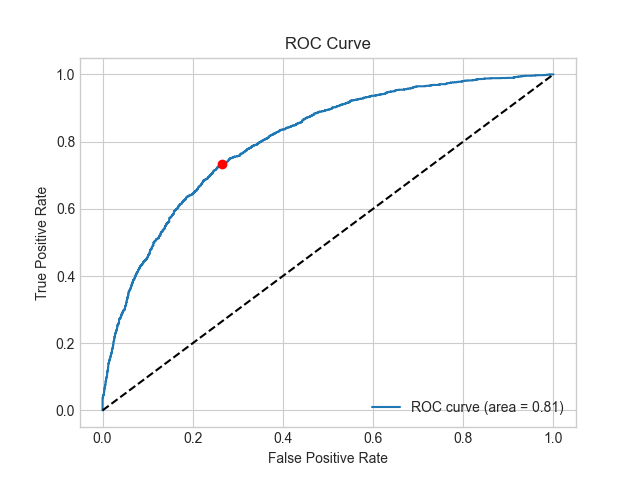

In [27]:
# ── Run evaluate_model() on final model ──────────────────────────────────────
final_eval_df = pd.DataFrame({
    'TARGET': y_test.values,
    'probs':  y_prob_final
})

final_plot_dir = f"{PLOT_DIR}/final_model"
os.makedirs(final_plot_dir, exist_ok=True)

final_auc, final_lift_10 = evaluate_model(final_eval_df, final_plot_dir)

print("="*50)
print(f"  FINAL MODEL: {BEST_MODEL_NAME} (Optuna Tuned)")
print("="*50)
print(f"  Test AUC          : {final_auc:.4f}")
print(f"  Lift (10th Decile): {final_lift_10:.4f}")
print(f"  Accuracy          : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"  Precision         : {precision_score(y_test, y_pred_final):.4f}")
print(f"  Recall            : {recall_score(y_test, y_pred_final):.4f}")
print(f"  F1 Score          : {f1_score(y_test, y_pred_final):.4f}")
print("="*50)

# Display saved ROC plot
from IPython.display import Image, display
display(Image(filename=f"{final_plot_dir}/roc_curve.png"))

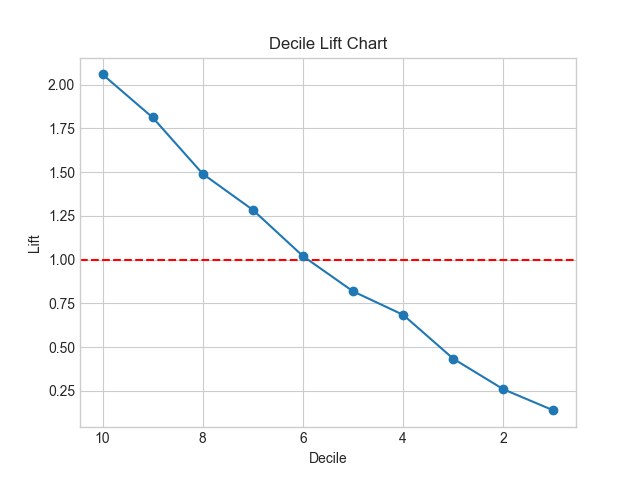

In [30]:
# ── Display Lift Chart ────────────────────────────────────────────────────────
display(Image(filename=f"{final_plot_dir}/lift_curve.png"))

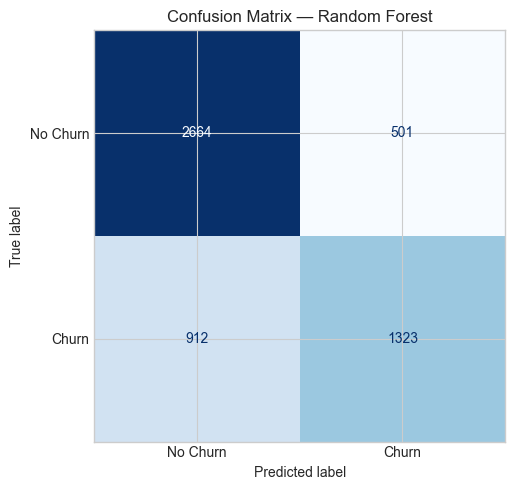

In [28]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/final_model/confusion_matrix.png", bbox_inches='tight', dpi=100)
plt.show()

---
## Step 14: Feature Importance

> **Business Value:** After building the model, the business team always asks:  
> *"Why does the model predict churn? What should we focus on?"*  
> Feature importance answers this — it bridges the gap between data science and decision-making.

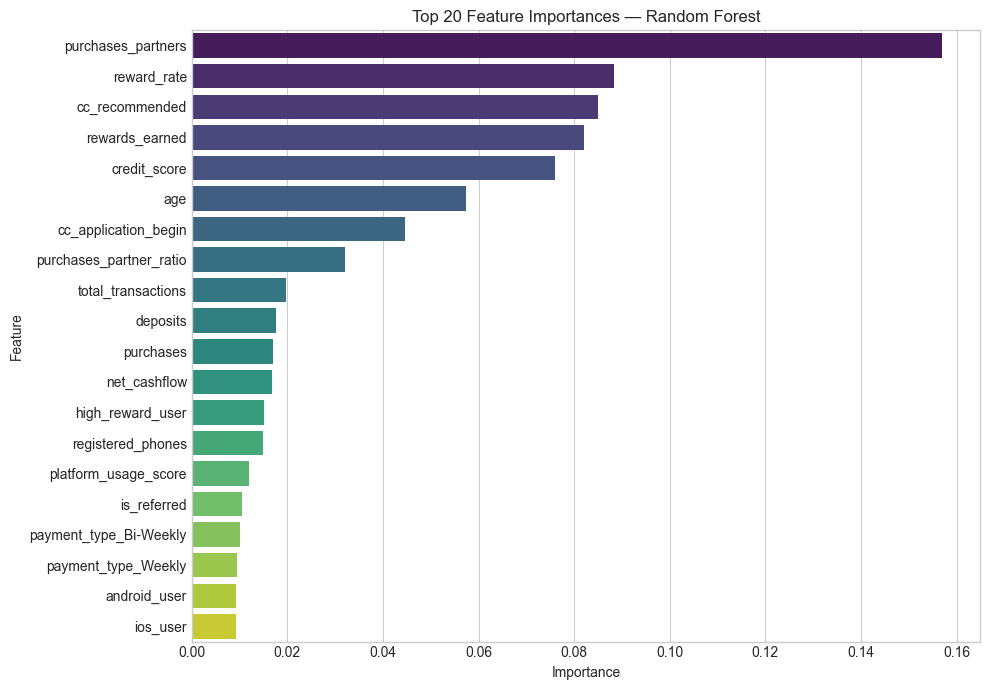

In [29]:
# Get feature names after preprocessing
num_feature_names = NUM_COLS_FE
try:
    cat_feature_names = list(
        preprocessor.named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(CAT_COLS_FE)
    )
except Exception:
    cat_feature_names = CAT_COLS_FE

all_feature_names = num_feature_names + cat_feature_names

# Extract feature importances (works for tree-based models)
if hasattr(final_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': all_feature_names[:len(final_model.feature_importances_)],
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f"Top 20 Feature Importances — {BEST_MODEL_NAME}")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/feature_importance.png", bbox_inches='tight', dpi=100)
    plt.show()
else:
    print("Feature importance not available for this model type.")

In [31]:
import mlflow
import mlflow.sklearn
import mlflow.xgboost

# ── MLflow Setup ──────────────────────────────────────────────────────────────
EXPERIMENT_NAME = "Churn_Prediction_MoneyLion"

mlflow.set_tracking_uri("mlruns")           # saves locally in mlruns/ folder
mlflow.set_experiment(EXPERIMENT_NAME)      # creates experiment if not exists

print(f"✅ MLflow Experiment: {EXPERIMENT_NAME}")

2026/03/14 08:38:42 INFO mlflow.tracking.fluent: Experiment with name 'Churn_Prediction_MoneyLion' does not exist. Creating a new experiment.


✅ MLflow Experiment: Churn_Prediction_MoneyLion


In [32]:
# ── Train all models in a loop + log to MLflow ───────────────────────────────

for model_name, model in MODEL_DICT.items():
    print(f"  ▶ {model_name}")

    with mlflow.start_run(run_name=model_name):   # ← each model = one run

        # ── Train ────────────────────────────────────────────────────────────
        model.fit(X_train_proc, y_train)
        trained_models[model_name] = model

        # ── Predict ──────────────────────────────────────────────────────────
        y_prob = model.predict_proba(X_test_proc)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        # ── Cross-Validation ─────────────────────────────────────────────────
        cv_scores = cross_val_score(
            model, X_train_proc, y_train,
            cv=cv_strategy, scoring='roc_auc', n_jobs=-1
        )

        # ── Evaluate (AUC + Lift) ─────────────────────────────────────────────
        eval_df_temp = pd.DataFrame({'TARGET': y_test.values, 'probs': y_prob})
        model_plot_dir = f"{PLOT_DIR}/{model_name.replace(' ', '_')}"
        os.makedirs(model_plot_dir, exist_ok=True)
        auc, lift_10th = evaluate_model(eval_df_temp, model_plot_dir)

        # ── Log Params ────────────────────────────────────────────────────────
        mlflow.log_param("model_name",   model_name)
        mlflow.log_param("train_size",   X_train_proc.shape[0])
        mlflow.log_param("test_size",    X_test_proc.shape[0])
        mlflow.log_param("n_features",   X_train_proc.shape[1])

        # ── Log Metrics ───────────────────────────────────────────────────────
        mlflow.log_metric("test_auc",        round(auc, 4))
        mlflow.log_metric("cv_auc_mean",     round(cv_scores.mean(), 4))
        mlflow.log_metric("cv_auc_std",      round(cv_scores.std(), 4))
        mlflow.log_metric("accuracy",        round(accuracy_score(y_test, y_pred), 4))
        mlflow.log_metric("precision",       round(precision_score(y_test, y_pred), 4))
        mlflow.log_metric("recall",          round(recall_score(y_test, y_pred), 4))
        mlflow.log_metric("f1_score",        round(f1_score(y_test, y_pred), 4))
        mlflow.log_metric("lift_10th_decile",round(lift_10th, 4))

        # ── Log Plots ─────────────────────────────────────────────────────────
        mlflow.log_artifact(f"{model_plot_dir}/roc_curve.png")
        mlflow.log_artifact(f"{model_plot_dir}/lift_curve.png")

        # ── Log Model ─────────────────────────────────────────────────────────
        mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"     AUC={auc:.4f}  CV={cv_scores.mean():.4f}  Lift={lift_10th:.4f}")

print("\n✅ All runs logged to MLflow!")

  ▶ Logistic Regression


2026/03/14 08:39:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 08:39:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


     AUC=0.7074  CV=0.6998  Lift=1.6555
  ▶ Decision Tree


2026/03/14 08:39:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 08:39:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


     AUC=0.7613  CV=0.7422  Lift=1.9584
  ▶ Random Forest


...

     AUC=0.7718  CV=0.7645  Lift=1.9687
  ▶ XGBoost


2026/03/14 08:39:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 08:39:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


     AUC=0.7976  CV=0.7832  Lift=2.0671
  ▶ LightGBM


2026/03/14 08:40:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 08:40:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


     AUC=0.7987  CV=0.7875  Lift=2.0582

✅ All runs logged to MLflow!


In [33]:
# ── Log final Optuna-tuned model ──────────────────────────────────────────────
with mlflow.start_run(run_name=f"{BEST_MODEL_NAME}_Optuna_Tuned"):

    # Log best hyperparameters found by Optuna
    for param_name, param_value in study.best_params.items():
        mlflow.log_param(param_name, param_value)

    mlflow.log_param("tuning_method",  "Optuna")
    mlflow.log_param("n_trials",        30)

    # Log final metrics
    mlflow.log_metric("test_auc",         round(final_auc, 4))
    mlflow.log_metric("lift_10th_decile", round(final_lift_10, 4))
    mlflow.log_metric("accuracy",         round(accuracy_score(y_test, y_pred_final), 4))
    mlflow.log_metric("f1_score",         round(f1_score(y_test, y_pred_final), 4))

    # Log plots
    mlflow.log_artifact(f"{PLOT_DIR}/final_model/roc_curve.png")
    mlflow.log_artifact(f"{PLOT_DIR}/final_model/lift_curve.png")
    mlflow.log_artifact(f"{PLOT_DIR}/optuna_history.png")

    # Log model
    mlflow.sklearn.log_model(final_model, artifact_path="best_model")

    print(f"✅ Best model logged: {BEST_MODEL_NAME} | AUC={final_auc:.4f}")

2026/03/14 08:40:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/14 08:40:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Best model logged: Random Forest | AUC=0.8059


In [34]:
import pickle
import os

# Create a models directory inside your ML_Project
MODELS_DIR = r"C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\ML_Project\models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Save final model
pickle_path = os.path.join(MODELS_DIR, "final_model_optuna.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(final_model, f)

print(f"✅ Model saved to: {pickle_path}")

✅ Model saved to: C:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\ML_Project\models\final_model_optuna.pkl


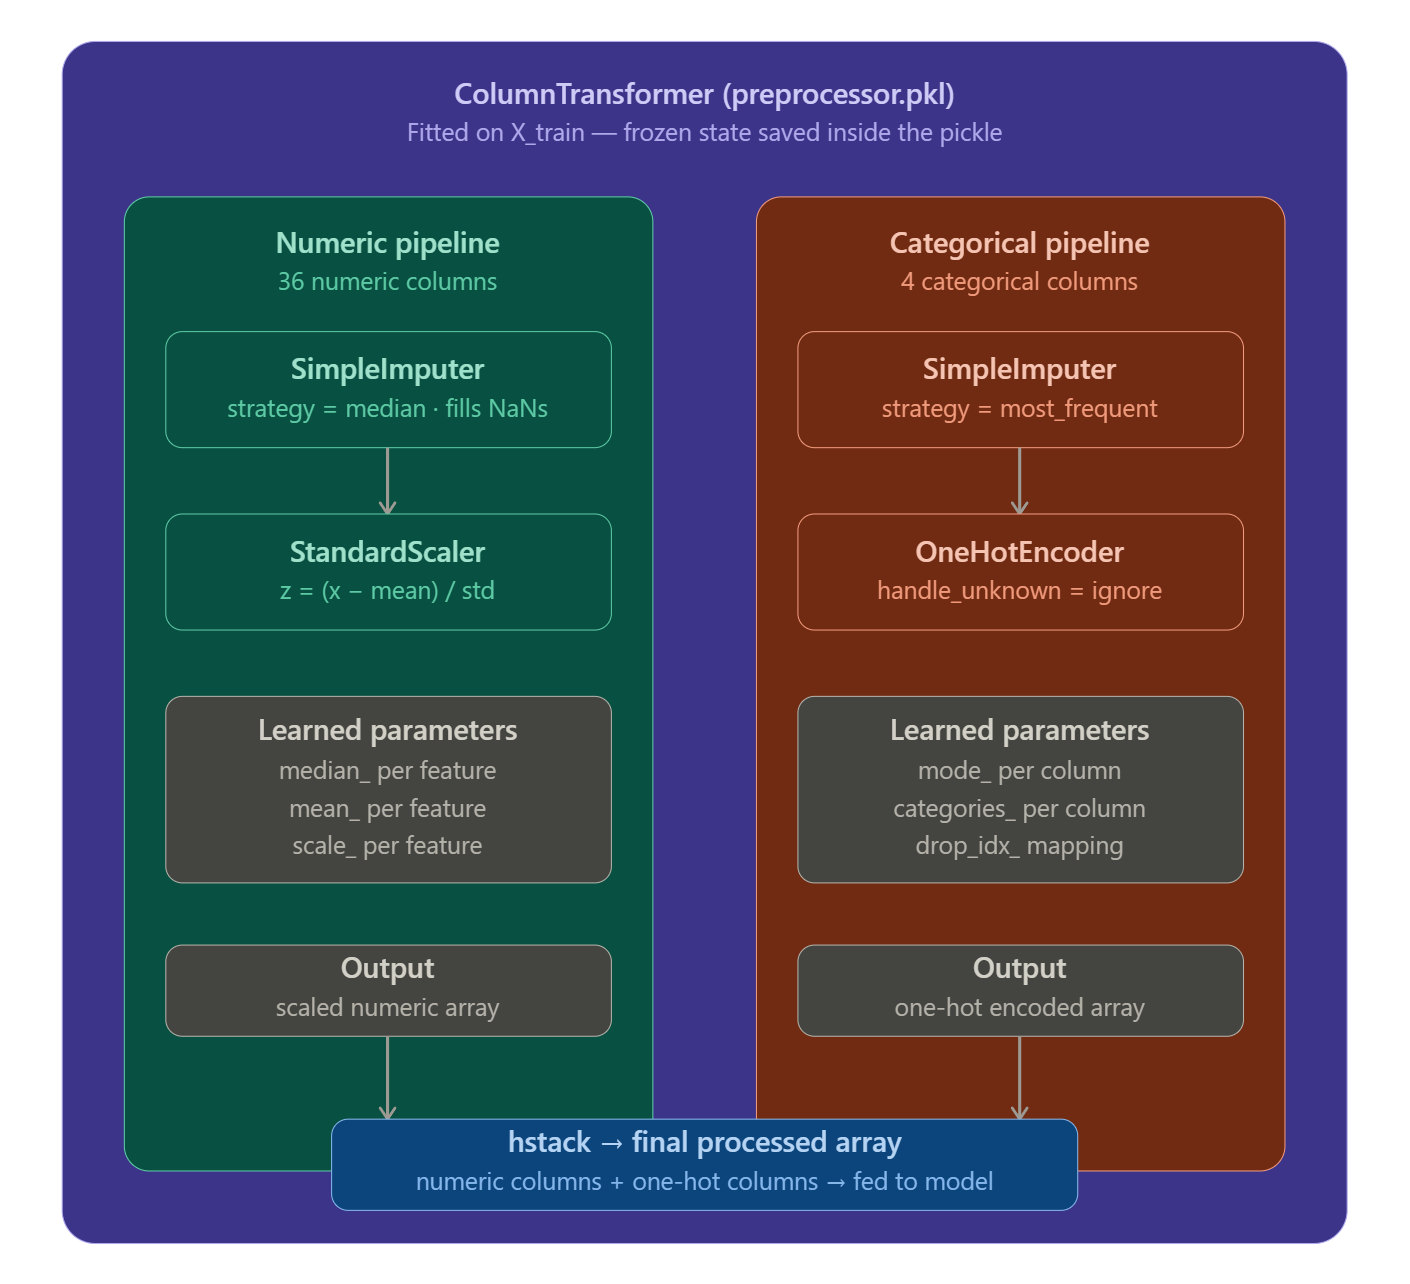

In [44]:
import pickle, os

MODELS_DIR = os.path.join(os.getcwd(), "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Save Preprocessor ─────────────────────────────────────────────────────────
preprocessor_path = os.path.join(MODELS_DIR, "preprocessor.pkl")
with open(preprocessor_path, "wb") as f:
    pickle.dump(preprocessor, f)
print(f"✅ Preprocessor saved : {preprocessor_path}")

# ── Verify it saved correctly by reloading ────────────────────────────────────
with open(preprocessor_path, "rb") as f:
    test_load = pickle.load(f)
print(f"✅ Verified reload    : {type(test_load).__name__}")

# ── Check file size ───────────────────────────────────────────────────────────
size_kb = os.path.getsize(preprocessor_path) / 1024
print(f"✅ File size          : {size_kb:.1f} KB")

# ── Show models folder ────────────────────────────────────────────────────────
print(f"\n📁 models/ folder:")
for f in os.listdir(MODELS_DIR):
    kb = os.path.getsize(os.path.join(MODELS_DIR, f)) / 1024
    print(f"   {f:<35} {kb:.1f} KB")

✅ Preprocessor saved : c:\Rehan\tut\Python\Introduction-to-Python-for-Data-Sciences\DPCOE\ML_Project\models\preprocessor.pkl
✅ Verified reload    : ColumnTransformer
✅ File size          : 5.6 KB

📁 models/ folder:
   final_model_optuna.pkl              91583.3 KB
   preprocessor.pkl                    5.6 KB


In [35]:
PICKLE_PATH = os.path.join(os.getcwd(), "models", "final_model_optuna.pkl")
 
with open(PICKLE_PATH, "rb") as f:
    loaded_model = pickle.load(f)
 
print(f"✅ Model loaded: {type(loaded_model).__name__}")

✅ Model loaded: RandomForestClassifier


In [36]:
np.random.seed(42)
N = 10
 
raw_new_data = pd.DataFrame({
    # Demographics
    'age':                   np.random.randint(18, 70, N).astype(float),
    'housing':               np.random.choice(['R', 'O'], N),
    'credit_score':          np.random.randint(300, 800, N).astype(float),
 
    # Transactions
    'deposits':              np.random.randint(0, 60, N),
    'withdrawal':            np.random.randint(0, 40, N),
    'purchases_partners':    np.random.randint(0, 100, N),
    'purchases':             np.random.randint(0, 80, N),
 
    # Credit Card Behaviour
    'cc_taken':              np.random.randint(0, 2, N),
    'cc_recommended':        np.random.randint(0, 300, N),
    'cc_disliked':           np.random.randint(0, 50, N),
    'cc_liked':              np.random.randint(0, 100, N),
    'cc_application_begin':  np.random.randint(0, 20, N),
 
    # App/Platform Usage
    'app_downloaded':        np.random.randint(0, 2, N),
    'web_user':              np.random.randint(0, 2, N),
    'app_web_user':          np.random.randint(0, 2, N),
    'ios_user':              np.random.randint(0, 2, N),
    'android_user':          np.random.randint(0, 2, N),
    'registered_phones':     np.random.randint(0, 3, N),
 
    # Loan Behaviour
    'payment_type':          np.random.choice(['Bi-Weekly', 'Weekly', 'Semi-Monthly', 'Monthly'], N),
    'waiting_4_loan':        np.random.randint(0, 2, N),
    'cancelled_loan':        np.random.randint(0, 2, N),
    'received_loan':         np.random.randint(0, 2, N),
    'rejected_loan':         np.random.randint(0, 2, N),
 
    # Miscellaneous
    'zodiac_sign':           np.random.choice([
                                'Leo','Capricorn','Aries','Taurus','Cancer',
                                'Sagittarius','Aquarius','Virgo','Libra',
                                'Gemini','Scorpio','Pisces'], N),
    'left_for_two_month_plus': np.random.randint(0, 2, N),
    'left_for_one_month':    np.random.randint(0, 2, N),
    'rewards_earned':        np.random.uniform(0, 200, N).round(1),
    'reward_rate':           np.random.uniform(0, 4, N).round(2),
    'is_referred':           np.random.randint(0, 2, N),
})
 
print(f"\n✅ Generated {N} new raw records")
print(raw_new_data.head())


✅ Generated 10 new raw records
    age housing  credit_score  deposits  withdrawal  purchases_partners  \
0  56.0       R         557.0        11          15                  88   
1  69.0       R         643.0        57          14                  59   
2  46.0       O         791.0        21           2                  13   
3  32.0       R         713.0        43          36                   8   
4  60.0       O         593.0        24           6                  89   

   purchases  cc_taken  cc_recommended  cc_disliked  cc_liked  \
0         70         1              43           15        14   
1         43         1             161           44        44   
2          7         1             201           17        64   
3         46         1             269           46        88   
4         34         1             270           23        70   

   cc_application_begin  app_downloaded  web_user  app_web_user  ios_user  \
0                    10               1         0

In [37]:
def create_features(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()
 
    # Engagement Features
    df['purchases_partner_ratio'] = np.where(
        df['purchases'] > 0,
        df['purchases_partners'] / (df['purchases'] + 1), 0
    )
    df['total_transactions']  = df['deposits'] + df['withdrawal'] + df['purchases']
    df['net_cashflow']        = df['deposits'] - df['withdrawal']
    df['platform_usage_score'] = (
        df['app_downloaded'] + df['web_user'] +
        df['app_web_user']   + df['ios_user'] + df['android_user']
    )
 
    # Credit Card Behaviour
    df['cc_engagement_ratio'] = np.where(
        df['cc_recommended'] > 0,
        df['cc_liked'] / (df['cc_recommended'] + 1), 0
    )
    df['cc_dissatisfaction_ratio'] = np.where(
        df['cc_recommended'] > 0,
        df['cc_disliked'] / (df['cc_recommended'] + 1), 0
    )
 
    # Loan Behaviour
    df['loan_interactions'] = (
        df['waiting_4_loan'] + df['cancelled_loan'] +
        df['received_loan']  + df['rejected_loan']
    )
    df['loan_rejection_rate'] = np.where(
        df['loan_interactions'] > 0,
        df['rejected_loan'] / (df['loan_interactions'] + 1), 0
    )
 
    # Reward & Loyalty
    df['high_reward_user'] = (df['reward_rate'] > df['reward_rate'].median()).astype(int)
 
    # Absence / Inactivity
    df['prolonged_absence'] = np.where(
        (df['left_for_two_month_plus'] == 1) | (df['left_for_one_month'] == 1), 1, 0
    )
 
    # Age Buckets
    df['age_group'] = pd.cut(
        df['age'],
        bins=[0, 25, 35, 45, 100],
        labels=['18-25', '26-35', '36-45', '45+']
    ).astype(str)
 
    return df
 
 
df_new_fe = create_features(raw_new_data)
print(f"\n✅ Feature engineering applied — shape: {df_new_fe.shape}")


✅ Feature engineering applied — shape: (10, 40)


In [42]:
CAT_COLS_FE = ['housing', 'payment_type', 'zodiac_sign', 'age_group']

NUM_COLS_FE = [
    'age', 'credit_score', 'deposits', 'withdrawal', 'purchases_partners',
    'purchases', 'cc_taken', 'cc_recommended', 'cc_disliked', 'cc_liked',
    'cc_application_begin', 'app_downloaded', 'web_user', 'app_web_user',
    'ios_user', 'android_user', 'registered_phones', 'waiting_4_loan',
    'cancelled_loan', 'received_loan', 'rejected_loan', 'left_for_two_month_plus',
    'left_for_one_month', 'rewards_earned', 'reward_rate', 'is_referred',
    # engineered features
    'purchases_partner_ratio', 'total_transactions', 'net_cashflow',
    'platform_usage_score', 'cc_engagement_ratio', 'cc_dissatisfaction_ratio',
    'loan_interactions', 'loan_rejection_rate', 'high_reward_user',
    'prolonged_absence'
]

ALL_FEATURES = NUM_COLS_FE + CAT_COLS_FE

X_new = df_new_fe[ALL_FEATURES]
print(f"✅ Features selected: {X_new.shape[1]} columns")

✅ Features selected: 40 columns


In [43]:
X_new_proc = preprocessor.transform(X_new)   # ← uses the already-fitted preprocessor
print(f"✅ Preprocessing done — shape: {X_new_proc.shape}")
 
 
# ══════════════════════════════════════════════════════════════════════════════
# STEP 6 — Predict & display results
# ══════════════════════════════════════════════════════════════════════════════
 
churn_prob  = loaded_model.predict_proba(X_new_proc)[:, 1]
churn_pred  = (churn_prob >= 0.5).astype(int)
risk_labels = ['🟢 Low Risk' if p < 0.4 else '🟡 Medium Risk' if p < 0.7 else '🔴 High Risk'
               for p in churn_prob]
 
results_df = pd.DataFrame({
    'Record #':        range(1, N + 1),
    'Age':             raw_new_data['age'].astype(int),
    'Housing':         raw_new_data['housing'],
    'Payment Type':    raw_new_data['payment_type'],
    'Churn Prob (%)':  (churn_prob * 100).round(2),
    'Prediction':      ['CHURN' if p == 1 else 'STAY' for p in churn_pred],
    'Risk Level':      risk_labels,
})
 
print("\n" + "═"*70)
print("           CHURN PREDICTION RESULTS — 10 NEW RECORDS")
print("═"*70)
print(results_df.to_string(index=False))
print("═"*70)
print(f"\n📊 Summary:")
print(f"   Predicted to CHURN : {churn_pred.sum()} / {N}")
print(f"   Predicted to STAY  : {N - churn_pred.sum()} / {N}")
print(f"   Avg Churn Prob     : {churn_prob.mean()*100:.1f}%")

✅ Preprocessing done — shape: (10, 58)

══════════════════════════════════════════════════════════════════════
           CHURN PREDICTION RESULTS — 10 NEW RECORDS
══════════════════════════════════════════════════════════════════════
 Record #  Age Housing Payment Type  Churn Prob (%) Prediction    Risk Level
        1   56       R Semi-Monthly           50.54      CHURN 🟡 Medium Risk
        2   69       R Semi-Monthly           33.29       STAY    🟢 Low Risk
        3   46       O       Weekly           43.71       STAY 🟡 Medium Risk
        4   32       R      Monthly           45.02       STAY 🟡 Medium Risk
        5   60       O       Weekly           46.29       STAY 🟡 Medium Risk
        6   25       O       Weekly           54.53      CHURN 🟡 Medium Risk
        7   38       O    Bi-Weekly           61.13      CHURN 🟡 Medium Risk
        8   56       R       Weekly           39.20       STAY    🟢 Low Risk
        9   36       O    Bi-Weekly           31.28       STAY    🟢 Low 

---
## Step 15: Conclusion & Key Learnings

### What we built in this notebook (Industry-Grade Pipeline):

| Step | Technique | Why it matters |
|------|-----------|----------------|
| Data Cleaning | Replace `'na'` with `NaN` | Prevents silent bugs in imputation |
| Feature Engineering | Ratios, interactions, groups | Creates new predictive signals |
| StratifiedShuffleSplit | Stratified train/test | Preserves class balance in both splits |
| ColumnTransformer Pipeline | Separate pipelines per type | No data leakage, reusable at inference |
| Normalization (StandardScaler) | Zero mean, unit variance | Prevents features dominating by scale |
| Multiple Model Training | Loop over model dict | Fair comparison before deep tuning |
| Cross-Validation | 5-fold StratifiedKFold | Reliable performance estimate |
| Optuna HPO | Bayesian optimization | Smarter than Grid/Random Search |
| evaluate_model() | AUC + Decile Lift | Business-meaningful evaluation |
| Feature Importance | Tree-based importances | Explains model to business stakeholders |

### Key Metrics Explained:
- **AUC (Area Under ROC Curve):** How well the model ranks churners above non-churners. AUC = 1.0 is perfect. AUC = 0.5 is random.
- **Decile Lift:** If you reach the top 10% of customers ranked by churn probability, how many more churners do you capture vs random selection? Lift of 2.0 = 2x better than random.
- **F1 Score:** Harmonic mean of Precision and Recall — useful for imbalanced targets.